# **Python Class 14 – Advanced NumPy & Introduction to Pandas**

In the previous lesson, we explored the foundations of NumPy:
vectorization, broadcasting, slicing, reshaping, and why NumPy arrays allow Python to achieve **C-level performance** for numerical computing. Today, we build on that knowledge and start moving toward one of the most important tools in all of data science — **Pandas**.

---

## **What We Will Learn Today**

### **1. More Advanced NumPy Concepts**

Before moving to Pandas, we reinforce your understanding of NumPy by exploring:

* Boolean masks and filtering
* Fancy indexing
* Aggregations and statistics (mean, std, sum, axis logic)
* Stacking and splitting arrays
* Memory views and copies
* Broadcasting in more complex shapes

This deeper understanding of NumPy is essential because **Pandas is built on top of NumPy**.

---

## **2. Introduction to Pandas — The Python Data Analysis Library**

Pandas is the industry-standard tool for:

* data cleaning
* data preprocessing
* data wrangling
* working with tabular datasets (CSV, Excel, SQL, JSON)

You will learn the two fundamental data structures:

### **✔ Series**

A 1-dimensional labeled array.

### **✔ DataFrame**

A 2-D table with labeled rows and columns — like an Excel sheet, but programmable.

---

## **Why Pandas Matters**

Pandas is the backbone of nearly every data science, ML, and analytics workflow:

* loading datasets efficiently
* inspecting and understanding data
* handling missing values
* joining and merging tables
* grouping and aggregating
* transforming columns
* preparing data for ML models

If NumPy makes Python fast, **Pandas makes Python usable** for real-world structured data.

---

## **3. The NumPy → Pandas Connection**

You will also see how:

* DataFrames are built on top of NumPy arrays
* vectorized operations still apply
* Pandas indexing works under the hood
* data types affect performance and memory

Understanding this connection now will make you much stronger in both libraries.

---

## **By the End of Today’s Class**

You will know:

* how to perform more advanced operations in NumPy
* how to create, explore, index, slice, and modify Pandas Series and DataFrames
* how Pandas simplifies data manipulation compared to raw Python lists or NumPy arrays

This class marks a major step in your journey — from just programming in Python to analyzing real data like a true data scientist.


# Computation on Arrays: Broadcasting
Recall that for arrays of the same size, binary operations are performed on an element-by-element basis:

In [ ]:
import numpy as np

In [ ]:
a = np.array([0, 1, 2])
b = np.array([5, 5, 5])
a + b

array([5, 6, 7])

Broadcasting allows these types of binary operations to be performed on arrays of different sizes–for example, we can just as easily add a scalar (think of it as a zero-dimensional array) to an array:

In [ ]:
a + 5

array([5, 6, 7])

We can think of this as an operation that stretches or duplicates the value `5` into the array `[5, 5, 5]`, and adds the results. The advantage of NumPy's broadcasting is that this duplication of values does not actually take place, but it is a useful mental model as we think about broadcasting.

We can similarly extend this to arrays of higher dimension. Observe the result when we add a one-dimensional array to a two-dimensional array:

In [ ]:
a = np.array([1, 2])
a

array([1, 2])

In [ ]:
M

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [ ]:
a.shape

(2,)

In [ ]:
M.shape

(3, 3)

In [ ]:
M = np.ones((3, 3))
M + a

ValueError: operands could not be broadcast together with shapes (3,3) (2,) 

## Rules of Broadcasting
Broadcasting in NumPy follows a strict set of rules to determine the interaction between the two arrays:

1. If the two arrays differ in their number of dimensions, the shape of the one with fewer dimensions is padded with ones on its leading (left) side.
2. If the shape of the two arrays does not match in any dimension, the array with shape equal to 1 in that dimension is stretched to match the other shape.
3. If in any dimension the sizes disagree and neither is equal to 1, an error is raised.

![alt text](https://jakevdp.github.io/PythonDataScienceHandbook/figures/02.05-broadcasting.png)

The light boxes represent the broadcasted values: again, this extra memory is not actually allocated in the course of the operation.

### Broadcasting example 1

In [ ]:
M = np.ones((2, 3))
a = np.arange(3)

Let's consider an operation on these two arrays. The shape of the arrays are

- ``M.shape = (2, 3)``
- ``a.shape = (3,)``

We see by rule 1 that the array ``a`` has fewer dimensions, so we pad it on the left with ones:

- ``M.shape -> (2, 3)``
- ``a.shape -> (1, 3)``

By rule 2, we now see that the first dimension disagrees, so we stretch this dimension to match:

- ``M.shape -> (2, 3)``
- ``a.shape -> (2, 3)``

The shapes match, and we see that the final shape will be ``(2, 3)``:

In [ ]:
M

array([[1., 1., 1.],
       [1., 1., 1.]])

In [ ]:
a

array([0, 1, 2])

In [ ]:
M + a

array([[1., 2., 3.],
       [1., 2., 3.]])

### Broadcasting example 2

Let's take a look at an example where both arrays need to be broadcast:

In [ ]:
a = np.arange(3).reshape((3, 1))
b = np.arange(3)

Again, we'll start by writing out the shape of the arrays:

- ``a.shape = (3, 1)``
- ``b.shape = (3,)``

Rule 1 says we must pad the shape of ``b`` with ones:

- ``a.shape -> (3, 1)``
- ``b.shape -> (1, 3)``

And rule 2 tells us that we upgrade each of these ones to match the corresponding size of the other array:

- ``a.shape -> (3, 3)``
- ``b.shape -> (3, 3)``

Because the result matches, these shapes are compatible. We can see this here:

In [ ]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

### Broadcasting example 3

Now let's take a look at an example in which the two arrays are not compatible:

In [ ]:
M = np.ones((3, 2))
a = np.arange(3)

This is just a slightly different situation than in the first example: the matrix ``M`` is transposed.
How does this affect the calculation? The shape of the arrays are

- ``M.shape = (3, 2)``
- ``a.shape = (3,)``

Again, rule 1 tells us that we must pad the shape of ``a`` with ones:

- ``M.shape -> (3, 2)``
- ``a.shape -> (1, 3)``

By rule 2, the first dimension of ``a`` is stretched to match that of ``M``:

- ``M.shape -> (3, 2)``
- ``a.shape -> (3, 3)``

Now we hit rule 3–the final shapes do not match, so these two arrays are incompatible, as we can observe by attempting this operation:

In [ ]:
M + a

ValueError: operands could not be broadcast together with shapes (2,3) (3,1) 

Note that while we've been focusing on the `+` operator here, these broadcasting rules apply to any binary `ufunc`.

# Comparisons, Masks, and Boolean Logic
This section covers the use of Boolean masks to examine and manipulate values within NumPy arrays. Masking comes up when you want to extract, modify, count, or otherwise manipulate values in an array based on some criterion: for example, you might wish to count all values greater than a certain value, or perhaps remove all outliers that are above some threshold. In NumPy, Boolean masking is often the most efficient way to accomplish these types of tasks.

## Comparison Operators as ufuncs

We have already introduced ufuncs, and focused in particular on arithmetic operators. We saw that using +, -, *, /, and others on arrays leads to element-wise operations. NumPy also implements comparison operators such as < (less than) and > (greater than) as element-wise ufuncs. The result of these comparison operators is always an array with a Boolean data type. All six of the standard comparison operations are available:

In [ ]:
x = np.array([[1, 2, 3, 4, 5],
              [4, 5, 6, 5, 4]])

In [ ]:
print('Less than: \n', x < 3, end = '\n\n')
print('Greater than: \n', x > 3, end = '\n\n')
print('Less than or equal: \n', x <= 3, end = '\n\n')
print('Less than or equal: \n', x >= 3, end = '\n\n')
print('Not equal: \n', x != 3, end = '\n\n')
print('Equal: \n', x == 3, end = '\n\n')
print('Multiple checkings: \n', (x == 3) * 1)

Less than: 
 [[ True  True False False False]
 [False False False False False]]

Greater than: 
 [[False False False  True  True]
 [ True  True  True  True  True]]

Less than or equal: 
 [[ True  True  True False False]
 [False False False False False]]

Less than or equal: 
 [[False False  True  True  True]
 [ True  True  True  True  True]]

Not equal: 
 [[ True  True False  True  True]
 [ True  True  True  True  True]]

Equal: 
 [[False False  True False False]
 [False False False False False]]

Multiple checkings: 
 [[0 0 1 0 0]
 [0 0 0 0 0]]


It is also possible to do an element-wise comparison of two arrays, and to include compound expressions:

In [ ]:
(2 * x) == (x ** 2)

array([[False,  True, False, False, False],
       [False, False, False, False, False]])

As in the case of arithmetic operators, the comparison operators are implemented as ufuncs in NumPy; for example, when you write                   

``x < 3``, internally NumPy uses ``np.less(x, 3)``.

A summary of the comparison operators and their equivalent ufunc is shown here:

| Operator | Equivalent ufunc   | Operator | Equivalent ufunc     |
|----------|---------------------|----------|------------------------|
| `==`     | `np.equal`          | `!=`     | `np.not_equal`        |
| `<`      | `np.less`           | `<=`     | `np.less_equal`       |
| `>`      | `np.greater`        | `>=`     | `np.greater_equal`    |


## Working with Boolean Arrays
Given a Boolean array, there are a host of useful operations you can do. We'll work with x, the two-dimensional array we created earlier.

### Counting entries
To count the number of True entries in a Boolean array, np.count_nonzero is useful:

In [ ]:
x < 6

array([[ True,  True,  True,  True,  True],
       [ True,  True, False,  True,  True]])

In [ ]:
# how many values less than 6?
print(x)
np.count_nonzero(x < 6)

[[1 2 3 4 5]
 [4 5 6 5 4]]


9

We see that there are eight array entries that are less than 6. Another way to get at this information is to use np.sum; in this case, False is interpreted as 0, and True is interpreted as 1:

In [ ]:
np.sum(x < 6)

np.int64(9)


The benefit of sum() is that like with other NumPy aggregation functions, this summation can be done along rows or columns as well:

In [ ]:
print(x)
np.sum(x < 6, axis = 0) # number of element in each row that are less than 6

[[1 2 3 4 5]
 [4 5 6 5 4]]


array([2, 2, 1, 2, 2])

If we're interested in quickly checking whether any or all the values are true, we can use (you guessed it) np.any or np.all:

In [ ]:
print(np.any(x > 8)) # are there any values greater than 8?
print(np.any(x < 0)) # are there any values less than zero?
print(np.all(x < 10)) # are all values less than 10?
print(np.all(x == 6)) # are all values equal to 6?
print(np.all(x < 8, axis=1)) # are all values in each row less than 8?

False
False
True
False
[ True  True]


In [ ]:
x = np.array([[1, 2, 3, 4, 5],
              [4, 5, 6, np.nan, 4]])

np.isnan(x)

array([[False, False, False, False, False],
       [False, False, False,  True, False]])

## Boolean operators

We can use bitwise logic operators, `&`, `|`, `^`, and `~`, in order to filter/get useful information from the data. Like with the standard arithmetic operators, NumPy overloads these as ufuncs which work element-wise on (usually Boolean) arrays.

Combining comparison operators and Boolean operators on arrays can lead to a wide range of efficient logical operations.

The following table summarizes the bitwise Boolean operators and their equivalent ufuncs:


| Operator | Equivalent ufunc     | Operator | Equivalent ufunc     |
|----------|------------------------|----------|------------------------|
| `&`      | `np.bitwise_and`       | `\|`      | `np.bitwise_or`        |
| `^`      | `np.bitwise_xor`       | `~`      | `np.bitwise_not`       |


### Boolean Arrays as Masks
In the preceding section we looked at aggregates computed directly on Boolean arrays. A more powerful pattern is to use Boolean arrays as masks, to select particular subsets of the data themselves. Returning to our x array from before, suppose we want an array of all values in the array that are less than, say, 5:

In [ ]:
x = np.array([[1, 2, 3, 4, 5],
              [4, 5, 6, 5, 4]])

In [ ]:
x < 5

array([[ True,  True,  True,  True, False],
       [ True, False, False, False,  True]])

Now to select these values from the array, we can simply index on this Boolean array; this is known as a masking operation:

In [ ]:
# x[x < 5]
x[(x < 5) | (x == 6)]

array([1, 2, 3, 4, 4, 6, 4])

In [ ]:
print(x < 5)
print(x == 4)
print((x < 5) ^ (x == 6))

[[ True  True  True  True False]
 [ True False False False  True]]
[[False False False  True False]
 [ True False False False  True]]
[[ True  True  True  True False]
 [ True False  True False  True]]


In [ ]:
~(x > 2)

array([[ True,  True, False, False, False],
       [False, False, False, False, False]])

What is returned is a one-dimensional array filled with all the values that meet this condition; in other words, all the values in positions at which the mask array is True.

## Aside: Using the Keywords and/or Versus the Operators &/|

One common point of confusion is the difference between the keywords ``and`` and ``or`` on one hand, and the operators ``&`` and ``|`` on the other hand.
When would you use one versus the other?

The difference is this: ``and`` and ``or`` gauge the truth or falsehood of *entire object*, while ``&`` and ``|`` refer to *bits within each object*.

When you use ``and`` or ``or``, it's equivalent to asking Python to treat the object as a single Boolean entity.
In Python, all nonzero integers will evaluate as True. Thus:

In [ ]:
bool(42), bool(0)

(True, False)

In [ ]:
bool(42 and 0)

False

In [ ]:
bool(42 or 0)

True

When you use ``&`` and ``|`` on integers, the expression operates on the bits of the element, applying the *and* or the *or* to the individual bits making up the number:

In [ ]:
bin(42)

'0b101010'

In [ ]:
bin(59)

'0b111011'

In [ ]:
bin(42 & 59)

'0b101010'

In [ ]:
bin(42 | 59)

'0b111011'

In [ ]:
bin(-7)

'-0b111'

Notice that the corresponding bits of the binary representation are compared in order to yield the result.

When you have an array of Boolean values in NumPy, this can be thought of as a string of bits where ``1 = True`` and ``0 = False``, and the result of ``&`` and ``|`` operates similarly to above:

In [ ]:
A = np.array([1, 0, 1, 0, 1, 0], dtype=bool)
print(A)
B = np.array([1, 1, 1, 0, 1, 1], dtype=bool)
A | B

[ True False  True False  True False]


array([ True,  True,  True, False,  True,  True])

Using ``or`` on these arrays will try to evaluate the truth or falsehood of the entire array object, which is not a well-defined value:

In [ ]:
A or B

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Similarly, when doing a Boolean expression on a given array, you should use ``|`` or ``&`` rather than ``or`` or ``and``:

In [ ]:
x = np.arange(10)
(x > 4) & (x < 8)

array([False, False, False, False, False,  True,  True,  True, False,
       False])

Trying to evaluate the truth or falsehood of the entire array will give the same ``ValueError`` we saw previously:

In [ ]:
(x > 4) and (x < 8)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

So remember this: ``and`` and ``or`` perform a single Boolean evaluation on an entire object, while ``&`` and ``|`` perform multiple Boolean evaluations on the content (the individual bits or bytes) of an object.
For Boolean NumPy arrays, the latter is nearly always the desired operation.

# Fancy Indexing
Fancy indexing is conceptually simple: it means passing an array of indices to access multiple array elements at once. For example, consider the following array:

In [ ]:
rand = np.random.RandomState(0)
x = rand.randint(100, size=10)
print('Original matrix: \n', x, end = '\n\n')
print('Accessing elements with 3, 7, 2 indexes: \n', [x[3], x[7], x[2]], end = '\n\n')

# Making list of indexes
index = [3, 7, 2]

print('Accesing elements by fancy indexing: \n', x[index], end = '\n\n')


Original matrix: 
 [44 47 64 67 67  9 83 21 36 87]

Accessing elements with 3, 7, 2 indexes: 
 [np.int64(67), np.int64(21), np.int64(64)]

Accesing elements by fancy indexing: 
 [67 21 64]



When using fancy indexing, the shape of the result reflects the shape of the index arrays rather than the shape of the array being indexed:

In [ ]:
ind = np.array([[3, 7],
                [4, 5]])

print('Original matrix: \n', x, end = '\n\n')

print('Shape of ind is important: \n', x[ind])

Original matrix: 
 [44 47 64 67 67  9 83 21 36 87]

Shape of ind is important: 
 [[67 21]
 [67  9]]


#### Indexing with an array of integers

In [ ]:
a = np.arange(0, 100, 10)
print('Orignal numpy array: ', a, end = '\n\n')

# note: [2, 3, 2, 4, 2] is a Python list
print('Accessing elements with list: ', a[[2, 3, 2, 4, 2]])

Orignal numpy array:  [ 0 10 20 30 40 50 60 70 80 90]

Accessing elements with list:  [20 30 20 40 20]


Indexing can be done with an array of integers, **where the same index is repeated several time.**

New values can be assigned with this kind of indexing.

In [ ]:
a[[4, 1]] = -100
a

array([   0, -100,   20,   30, -100,   50,   60,   70,   80,   90])

This works for multidimentional arrays as well:

In [ ]:
X = np.arange(12).reshape((3, 4))
X

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

Like with standard indexing, the first index refers to the row, and the second to the column:

In [ ]:
row = np.array([0, 1, 2])
col = np.array([2, 1, 3])
X[row, col]

array([ 2,  5, 11])

## Combined Indexing
For even more powerful operations, fancy indexing can be combined with the other indexing schemes we've seen:

In [ ]:
print(X)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [ ]:
print('Combine fancy and simple indices: \n', X[2, [2, 0, 1]], end = '\n\n')
print('Combine fancy indexing with slicing: \n', X[1:, [2, 0, 1]], end = '\n\n')

#Making masking
mask = np.array([1, 0, 1, 0], dtype=bool)
print('Combine fancy indexing with masking: \n', X[row[:, np.newaxis], mask], end = '\n\n')

Combine fancy and simple indices: 
 [10  8  9]

Combine fancy indexing with slicing: 
 [[ 6  4  5]
 [10  8  9]]

Combine fancy indexing with masking: 
 [[ 0  2]
 [ 4  6]
 [ 8 10]]



# Sorting Arrays

There are built-in NumPy methods that sort arrays efficiently:
`np.sort` and `np.argsort`.

Although Python has built-in sort and sorted functions to work with lists, we won't discuss them here because NumPy's np.sort function turns out to be much more efficient and useful for our purposes. By default np.sort uses an $O(n \log n)$, quicksort algorithm, though mergesort and heapsort are also available.


In [ ]:
def quicksort(arr: np.array) -> np.array:
    if len(arr) <= 1:
        return arr

    pivot = arr[len(arr) // 2]

    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]

    return quicksort(left) + middle + quicksort(right)

In [ ]:
big_array = np.random.rand(1_000_000)
%timeit sorted(big_array)
%timeit np.sort(big_array)
%timeit quicksort(big_array)

1.26 s ± 247 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
28.6 ms ± 6.58 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
7.28 s ± 538 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
x = np.array([2, 1, 4, 3, 5])
# quicksort(x)
i = np.argsort(x)
print(i)

[1 0 3 2 4]


These indices can then be used (via fancy indexing) to construct the sorted array if desired:

In [ ]:
x[i]

array([1, 2, 3, 4, 5])

## Sorting along rows or columns
A useful feature of NumPy's sorting algorithms is the ability to sort along specific rows or columns of a multidimensional array using the axis argument.

In [ ]:
rand = np.random.RandomState(4)
#rand = np.random.RandomState(0)
X = rand.randint(0, 10, (2, 3))
print(X)

[[7 5 1]
 [8 7 8]]


In [ ]:
print('Sort each column of X: \n', np.sort(X, axis=0), end = '\n\n')
print('Sort each row of X: \n', np.sort(X, axis=1))

Sort each column of X: 
 [[7 5 1]
 [8 7 8]]

Sort each row of X: 
 [[1 5 7]
 [7 8 8]]


# Numpy for Linear Algebra

By now we are already familiar with a range concepts of linear algebra - the branch of mathematics concerned with vector spaces and the mappings between those spaces. **NumPy** has a package called **linalg** which includes functions for implementing standard linear algebra algorithms. Those functions rely on libraries that provide efficient low level implementations of standard linear algebra algorithms. Those libraries are
 * BLAS (Basic Linear Algebra Subprograms) - software library written in Fortran that provides low-level routines for performing common linear algebra operations such as vector addition, scalar multiplication, dot products, linear combinations, and matrix multiplication.
 * LAPACK (Linear Algebra Package) - software library written in *Fortran 90* that provides routines for solving systems of linear equations and linear least squares, eigenvalue problems, and matrix decomposition.
 The above mentioned libraries provide efficient low level implementations

## Matrix and vector products

In [ ]:
# similarly we can construct matrices
# we can multiply matrices with
a = np.array([
              [2, 3, 1],
              [3, -1, 0]  # 2 x 3
])

b = np.array([
              [1, -3],
              [4, 0],
              [2, -2]   # 3 x 2
])

print(a.shape)
print(b.shape)

(2, 3)
(3, 2)


## Transposing Matrices

In [ ]:
# get the transpose of the matrix
print('First method', np.transpose(b), sep='\n', end='\n\n')
print('Second method', b.T, sep='\n', end='\n\n')
print('Third method', b.transpose(), sep='\n', end='\n\n')

First method
[[ 1  4  2]
 [-3  0 -2]]

Second method
[[ 1  4  2]
 [-3  0 -2]]

Third method
[[ 1  4  2]
 [-3  0 -2]]



## Inverting Matrices

In [ ]:
# d = np.array([[3, 2, 3],
#               [1, 3, 4],
#               [3, 4, 5]]) # 3 x 3
#

d = np.array([[1, 2, 3],
              [4, 5, 6],
            [7, 8, 9]]) # 3 x 3



# get the inverse matrix
d_inv = np.linalg.inv(d)
print('Inverse Matrix', d_inv, sep='\n', end='\n\n')
print("Checking the inverse d' * d", np.around(d_inv @ d, 2),
      sep='\n', end='\n\n')
print("Checking the inverse d * d'", abs(np.around(d @ d_inv, 2)), sep='\n')

LinAlgError: Singular matrix

In [ ]:
# transpose of a transpose is the initial matrix
print(b, end='\n\n')
print(b.T.T)

[[ 1 -3]
 [ 4  0]
 [ 2 -2]]

[[ 1 -3]
 [ 4  0]
 [ 2 -2]]


In [ ]:
# we can multiply matrices using the following commands
# 2 x 3 * 3 x 2 = 2 x 2
print('First method', a.dot(b), sep='\n', end='\n\n')
print('Second method', np.matmul(a, b), sep='\n', end='\n\n')
print('The shortest method', a @ b, sep='\n')

First method
[[16 -8]
 [-1 -9]]

Second method
[[16 -8]
 [-1 -9]]

The shortest method
[[16 -8]
 [-1 -9]]


In [ ]:
# create an itentity matrix
identity_matrix = np.eye(3)
print(identity_matrix, end='\n\n')

# checking one of the properties of the identity matrix
print(a @ identity_matrix, end='\n\n')

# checking if the corresponding elements are the same
print(a @ identity_matrix == a, end='\n\n')

# checking if the matrices are the same
print('Checking the equality of arrays (method 1):',
      (a @ identity_matrix == a).all())
# or
print('Checking the equality of arrays (method 2):',
      np.allclose(a @ identity_matrix, a))

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

[[ 2.  3.  1.]
 [ 3. -1.  0.]]

[[ True  True  True]
 [ True  True  True]]

Checking the equality of arrays (method 1): True
Checking the equality of arrays (method 2): True


In [ ]:
# let's check some other properties of matrices
c = np.array([
              [2, 0, 4, 5, -9],  # 2 x 5
              [1, 4, 3, 8, -2]
])

# associativity:
# for a, b, c matrices with dim(a)=m x n, dim(b)=n x p, dim(c)=p x q
# (a*b)*c=a*(b*c)
# in our case dim(a)=2 x 3, dim(b)=3 x 2, dim(c)=2 x 5
print((a @ b) @ c, end='\n\n')
print(a @ (b @ c))

[[  24  -32   40   16 -128]
 [ -11  -36  -31  -77   27]]

[[  24  -32   40   16 -128]
 [ -11  -36  -31  -77   27]]


In [ ]:
# distributivity:
# for a, b, c with dim(a)=dim(b)=m x n, dim(c)=n x p
# in our case dim(a)=2 x 3, dim(a.T)=dim(b)=3 x 2
print((a.T + b) @ c, end='\n\n')
print(a.T @ c + b @ c)

[[  6   0  12  15 -27]
 [ 13  -4  25  27 -61]
 [  4  -8   6  -1 -23]]

[[  6   0  12  15 -27]
 [ 13  -4  25  27 -61]
 [  4  -8   6  -1 -23]]


Now let's compute inner products of given vectors

In [ ]:
# defining column vectors
x = np.array([[1, 2, 3]]).T
y = np.array([[2, 3, 4]]).T

# if the inputs of np.dot are 1d arrays it returns the inner product
# we saw above that for 2d arrays it is the matrix multiplication
print('Method 1:', np.dot(x.T, y))

# np.vdot computes the dot product between 2 vectors
# if we give multidimensional arrays as inputs it flattens them and
# computes the dot product, instead of matrix product
print('Method 2:', np.vdot(x, y))

# computing via the formula of dot product
print('Method 3:', x.T @ y)

# matrix multiplication for 1d arrays
print('Method 4:', np.matmul(x.T, y))

# takes column vectors as input
print('Method 5:', np.inner(x.T, y.T))

Method 1: [[20]]
Method 2: 20
Method 3: [[20]]
Method 4: [[20]]
Method 5: [[20]]


In [ ]:
# (a+b)^T=a^T + b^T
print((a.T+b).T, end='\n\n')
print(a + b.T)

[[ 3  7  3]
 [ 0 -1 -2]]

[[ 3  7  3]
 [ 0 -1 -2]]


## Solving equations

Suppose we want to solve $$A\boldsymbol{x}=b$$

In [ ]:
# solving Ax=b linear equation
A = np.array([
              [3, 1],
              [1, 2]
])

b = np.array([9, 8])

x = np.linalg.solve(A, b)
print(x, end='\n\n')

# checking the solution
print(np.allclose(A @ x, b))

[2. 3.]

True


Using the inverse of A
$$A^{-1}A\boldsymbol{x}=A^{-1}b \Rightarrow
 \boldsymbol{x}=A^{-1}b$$

In [ ]:
print(np.linalg.inv(A) @ b)

[2. 3.]


Suppose $A$ is not a square matrix, we can find an approximate solution to the equation $A\boldsymbol{x}=b$ using the least squares method, finding $\boldsymbol{x}$ that minimizes $||A\boldsymbol{x}-b||^{2}$  

In [ ]:
A = np.array([[2, 0],
              [-1, 1],
              [0, 2]])

b = np.array([1, 0, -1])

print(np.linalg.lstsq(A, b, rcond=None)[0])

[ 0.33333333 -0.33333333]


If $A$ has linearly independent columns (left-invertible), then the vector $$\hat{\boldsymbol{x}}=(A^{T}A)^{-1}A^{T}b=A^{\dagger}b,$$
where $A^{\dagger}$ is the *pseudo-inverse* of a left-invertible matrix.

In [ ]:
print(np.linalg.inv(A.T @ A) @ A.T @ b)
print(np.linalg.pinv(A))

[ 0.33333333 -0.33333333]
[[ 0.41666667 -0.16666667  0.08333333]
 [ 0.08333333  0.16666667  0.41666667]]


# Pandas

## Install and import
Pandas is an easy package to install. Open up your terminal program (for Mac users) or command line (for PC users) and install it using either of the following commands:

`conda install pandas`

or

`pip install pandas`

Alternatively, if you're currently viewing this article in a Jupyter notebook you can run this cell:

`!pip install pandas`

To import pandas we usually import it with a shorter name since it's used so much:

In [ ]:
import pandas as pd
import numpy as np # we will also need numpy in our examples

Most commonly used data structures in pandas are:


1.   Series objects: 1D array, similar to a column in a spreadsheet
2.   DataFrame objects: 2D table, similar to a spreadsheet

# Series
Series is a one-dimensional labeled array capable of holding any data type (integers, strings, floating point numbers, Python objects, etc.). The axis labels are collectively referred to as the index. The basic method to create a Series is to call:

In [ ]:
data = pd.Series([0.25, 0.5, 0.75, 1.0])
print(data, end = '\n\n')
print(type(data))

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

<class 'pandas.core.series.Series'>


As we see in the output, the *Series* wraps both a sequence of values and a sequence of indices, which we can access with the values and index attributes.

In [ ]:
print(data.values)
print(data.index)

[0.25 0.5  0.75 1.  ]
RangeIndex(start=0, stop=4, step=1)


In [ ]:
# Like with a NumPy array, data can be accessed by the associated index via the familiar Python square-bracket notation
print(data[1])
print(data[1:3])

0.5
1    0.50
2    0.75
dtype: float64


## Series as generalized NumPy array
Though Series are similar to one-dimensional NumPy array, there is an essential difference between them: the presence of index. While the Numpy Array has an implicitly defined integer index used to access the values, the Pandas Series has an explicitly defined index associated with the values.

In [ ]:
# we can use string as an index (values of other types are also allowed)
data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=['a', 'b', 'c', 'd'])
data

,0
a,0.25
b,0.50
c,0.75
d,1.00


In [ ]:
# In this case item access works like this:
print(data['b'])
print(data[1])

0.5
0.5


/tmp/ipython-input-4210053871.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(data[1])


In [ ]:
# Non-contiguous or non-sequential indices can be used as well
data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=[2, 5, 3, 7])
data

,0
2,0.25
5,0.50
3,0.75
7,1.00


In [ ]:
# Access of an item with index = 5
data[1]

/tmp/ipython-input-3651355480.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data[1]


np.float64(0.5)

## Series as specialized dictionary
Pandas Series can be thought of as Python dictionary.  A dictionary is a structure that maps arbitrary keys to a set of arbitrary values, and a Series is a structure which maps typed keys to a set of typed values.

In [ ]:
# By default, a Series will be created
#  where the index is drawn from the sorted keys.
population_dict = {'California': 38332521,
                   'Texas': 26448193,
                   'New York': 19651127,
                   'Florida': 19552860,
                   'Illinois': 12882135}
population = pd.Series(population_dict)
population

,0
California,38332521
Texas,26448193
New York,19651127
Florida,19552860
Illinois,12882135


In [ ]:
population['Texas']

np.int64(26448193)

Unlike a dictionary, though, the Series also supports array-style operations such as slicing:

In [ ]:
population['California':'Florida']

,0
California,38332521
Texas,26448193
New York,19651127
Florida,19552860


## Constructing Series objects

```Python
pd.Series(data, index=index)
```

where **index** is an optional argument, and **data** can be a list or NumPy array. In this case index defaults to an integer sequence.

In [ ]:
pd.Series([2, 4, 6])

,0
0,2
1,4
2,6


In [ ]:
# data can be a scalar
pd.Series(77, index=[111, 222, 333])

,0
111,77
222,77
333,77


`data` can be a dictionary, in which index defaults to the sorted dictionary keys:

In [ ]:
pd.Series({2:'a', 1:'b', 3:'c'})

,0
2,a
1,b
3,c


In [ ]:
# The index can be explicitly set.
# Series is populated only with the explicitly identified keys.
pd.Series({2:'a', 1:'b', 3:'c'}, index=[1, 2])

,0
1,b
2,a


# The Pandas DataFrame Object
`DataFrame` is another fundamental structure in Pandas. It can be thought of either as a generalization of a NumPy array, or as a specialization of a Python dictionary.

## DataFrame as a generalized NumPy array
If a Series is an analog of a one-dimensional array with flexible indices, a DataFrame is an analog of a two-dimensional array with both flexible row indices and flexible column names.

Just as we might think of a two-dimensional array as an ordered sequence of aligned one-dimensional columns, we can think of a DataFrame as a sequence of aligned Series objects. Here, by "aligned" we mean that they share the same index.

In [ ]:
# Firstly we create a new Series object with dict.
area_dict = {'California': 423967,
             'Texas': 695662,
             'New York': 141297,
             'Florida': 170312,
             'Illinois': 149995}
area = pd.Series(area_dict)
area

,0
California,423967
Texas,695662
New York,141297
Florida,170312
Illinois,149995


In [ ]:
# Now we can use a dictionary to construct a single two-dimensional
# object containing this information from population and area_dict
states = pd.DataFrame({'population': population,
                       'area': area})
states

,population,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


from matplotlib import pyplot as plt
_df_0['population'].plot(kind='hist', bins=20, title='population')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['area'].plot(kind='hist', bins=20, title='area')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('index').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3.plot(kind='scatter', x='population', y='area', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_5['area'].plot(kind='line', figsize=(8, 4), title='area')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_6['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_6, x='population', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_7['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_7, x='area', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

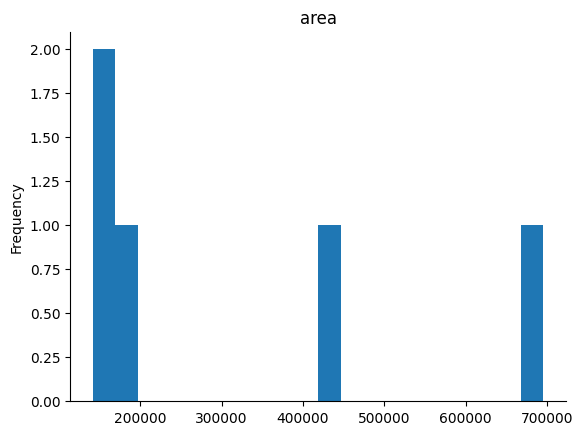

In [ ]:
from matplotlib import pyplot as plt
_df_1['area'].plot(kind='hist', bins=20, title='area')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# DataFrame has an index and column attributes that
# gives access to the index labels
print(states.index)
print(states.columns)
print(states.values)

Index(['California', 'Texas', 'New York', 'Florida', 'Illinois'], dtype='object')
Index(['population', 'area'], dtype='object')
[[38332521   423967]
 [26448193   695662]
 [19651127   141297]
 [19552860   170312]
 [12882135   149995]]


## DataFrame as specialized dictionary
Similarly, we can also think of a DataFrame as a specialization of a dictionary. Where a dictionary maps a key to a value, a DataFrame maps a column name to a Series of column data. For example, asking for the 'area' attribute returns the Series object containing the areas we saw earlier.

In [ ]:
states['area']

,area
California,423967
Texas,695662
New York,141297
Florida,170312
Illinois,149995


## Constructing DataFrame objects
A Pandas DataFrame can be constructed in a variety of ways. Here we'll give several examples.

### From a single Series object

A DataFrame is a collection of Series objects, and a single-column DataFrame can be constructed from a single Series.

In [ ]:
pd.DataFrame(population, columns=['population'])

,population
California,38332521
Texas,26448193
New York,19651127
Florida,19552860
Illinois,12882135


In [ ]:
pd.DataFrame([population, area], index=['population', 'area']).T

,population,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


### From a list of dicts
Any list of dictionaries can be made into a DataFrame. We'll use a simple list comprehension to create some data.

In [ ]:
data = [{'a': i, 'b': 2 * i}
        for i in range(3)]

pd.DataFrame(data)

,a,b
0,0,0
1,1,2
2,2,4


Even if some keys in the dictionary are missing, Pandas will fill them in with NaN (i.e., "not a number") values:

In [ ]:
pd.DataFrame([{'a': 1, 'b': 2},
              { 'a': 1, 'b': 3, 'c': 4}])

,a,b,c
0,1,2,NaN
1,1,3,4.0


### From a dictionary of Series objects
As we saw before, a DataFrame can be constructed from a dictionary of Series objects as well:

In [ ]:
pd.DataFrame({'population': population,
              'area': area})

,population,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


### From a two-dimensional NumPy array

Given a two-dimensional array of data, we can create a DataFrame with any specified column and index names. If omitted, an integer index will be used for each:

In [ ]:
pd.DataFrame(np.random.rand(3, 2),
             columns=['col_1', 'col_2'],
             index=['row_1', 'row_2', 'row_3'])

,col_1,col_2
row_1,0.974813,0.726625
row_2,0.699033,0.136701
row_3,0.997284,0.596123


# The Pandas Index Object
This Index object is an interesting structure in itself, and it can be thought of either as an immutable array or as an ordered set.


In [ ]:
ind = pd.Index([2, 3, 5, 7, 11])
ind

Index([2, 3, 5, 7, 11], dtype='int64')

## Index as immutable array
The Index in many ways operates like an array. For example, we can use standard Python indexing notation to retrieve values or slices.

In [ ]:
print(ind[1])
print(ind[::2])

3
Index([2, 5, 11], dtype='int64')


`Index` objects also have many of the attributes familiar from NumPy arrays.

In [ ]:
ind

Index([2, 3, 5, 7, 11], dtype='int64')

In [ ]:
print(ind.size, ind.shape, ind.ndim, ind.dtype)

5 (5,) 1 int64


In [ ]:
# It is immutable
ind[2] = 4

TypeError: Index does not support mutable operations

## Index as ordered set

Pandas objects are designed to facilitate operations such as joins across datasets, which depend on many aspects of set arithmetic.
The ``Index`` object follows many of the conventions used by Python's built-in ``set`` data structure, so that unions, intersections, differences, and other combinations can be computed in a familiar way:

In [ ]:
indA = pd.Index([1, 3, 5, 7, 9])
indB = pd.Index([2, 3, 5, 7, 11])

In [ ]:
bin(1)

'0b1'

In [ ]:
bin(2)

'0b10'

In [ ]:
bin(3)

'0b11'

In [ ]:
bin(0)

'0b0'

In [ ]:
print(indA & indB)
print(indA | indB)
print(indA ^ indB)

Index([0, 3, 5, 7, 1], dtype='int64')
Index([3, 3, 5, 7, 11], dtype='int64')
Index([3, 0, 0, 0, 10], dtype='int64')


# Data Indexing and Selection


## Data Selection in Series
As we saw in the previous section, a Series object acts in many ways like a one-dimensional NumPy array, and in many ways like a standard Python dictionary.

## Series as dictionary
Like a dictionary, the Series object provides a mapping from a collection of keys to a collection of values:

In [ ]:
data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=['a', 'b', 'c', 'd'])
data

,0
a,0.25
b,0.50
c,0.75
d,1.00


In [ ]:
data['b']

np.float64(0.5)

We can also use dictionary-like Python expressions and methods to examine the keys/indices and values:

In [ ]:
print('a' in data)
print(data.keys())
print(list(data.items()))

True
Index(['a', 'b', 'c', 'd'], dtype='object')
[('a', 0.25), ('b', 0.5), ('c', 0.75), ('d', 1.0)]


Series objects can even be modified with a dictionary-like syntax. Just as you can extend a dictionary by assigning to a new key, you can extend a Series by assigning to a new index value:

In [ ]:
data['e'] = 1.25
data

,0
a,0.25
b,0.50
c,0.75
d,1.00
e,1.25


## Series as one-dimensional array
A Series builds on this dictionary-like interface and provides array-style item selection via the same basic mechanisms as NumPy arrays – that is, slices, masking, and fancy indexing.


In [ ]:
data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=['a', 'b', 'c', 'd'])

# slicing by explicit index
data['a':'c'] # 2:5 -> 2,3,4

,0
a,0.25
b,0.50
c,0.75


In [ ]:
# slicing by implicit integer index
data[0:2]

,0
a,0.25
b,0.50


In [ ]:
# masking
data[(data > 0.3) & (data < 0.8)]

,0
b,0.50
c,0.75


Note that when slicing with **explicitly indexing** (i.e., `data['a':'c']`) the **final index is included**, whereas with implicit indexing (i.e., `data[0:2]`), it is excluded.

## Indexers: loc, iloc
If Series has an explicit integer index, an indexing operation such as data[1] will use the explicit indices, while a slicing operation like data[1:3] will use the implicit Python-style index.

In [ ]:
data = pd.Series(['a', 'b', 'c'], index=[1, 3, 5])
data

,0
1,a
3,b
5,c


In [ ]:
# explicit index when indexing
data[1]

'a'

In [ ]:
data[2:3]

,0
5,c


In [ ]:
# implicit index when slicing
data[1:3]

,0
3,b
5,c


Because of this potential confusion in the case of integer indexes, Pandas provides some special indexer attributes.

First, the ``loc`` attribute allows indexing and slicing that always references the explicit index:

In [ ]:
data.loc[1]

'a'

In [ ]:
data.loc[1:3]

,0
1,a
3,b


The ``iloc`` attribute allows indexing and slicing that always references the implicit Python-style index:

In [ ]:
data.iloc[1]

'b'

In [ ]:
data.iloc[1:3]

,0
3,b
5,c


## Data Selection in DataFrame
`DataFrame` acts in many ways like a two-dimensional or structured array, and in other ways like a dictionary of Series structures sharing the same index.

### DataFrame as a dictionary
The first analogy we will consider is the DataFrame as a dictionary of related Series objects.

In [ ]:
area = pd.Series({'California': 423967, 'Texas': 695662,
                  'New York': 141297, 'Florida': 170312,
                  'Illinois': 149995})
pop = pd.Series({'California': 38332521, 'Texas': 26448193,
                 'New York': 19651127, 'Florida': 19552860,
                 'Illinois': 12882135})
data = pd.DataFrame({'area': area, 'pop': pop})
data

,area,pop
California,423967,38332521
Texas,695662,26448193
New York,141297,19651127
Florida,170312,19552860
Illinois,149995,12882135


The individual Series that make up the columns of the DataFrame can be accessed via dictionary-style indexing of the column name:

In [ ]:
data['area']

,area
California,423967
Texas,695662
New York,141297
Florida,170312
Illinois,149995


Equivalently, we can use attribute-style access with column names that are strings:

In [ ]:
data.area

,area
California,423967
Texas,695662
New York,141297
Florida,170312
Illinois,149995


Dictionary-style syntax can also be used to modify the object, in this case adding a new column:

In [ ]:
data['density'] = data['pop'] / data['area']
data

,area,pop,density
California,423967,38332521,90.413926
Texas,695662,26448193,38.018740
New York,141297,19651127,139.076746
Florida,170312,19552860,114.806121
Illinois,149995,12882135,85.883763


### DataFrame as two-dimensional array
We can also view the DataFrame as an enhanced two-dimensional array. We can examine the raw underlying data array using the **values** attribute:

In [ ]:
data.values

array([[4.23967000e+05, 3.83325210e+07, 9.04139261e+01],
       [6.95662000e+05, 2.64481930e+07, 3.80187404e+01],
       [1.41297000e+05, 1.96511270e+07, 1.39076746e+02],
       [1.70312000e+05, 1.95528600e+07, 1.14806121e+02],
       [1.49995000e+05, 1.28821350e+07, 8.58837628e+01]])

Many familiar array-like observations can be done on the `DataFrame` itself. For example, we can transpose the full `DataFrame` to swap rows and columns:

In [ ]:
data.T

,California,Texas,New York,Florida,Illinois
area,4.239670e+05,6.956620e+05,1.412970e+05,1.703120e+05,1.499950e+05
pop,3.833252e+07,2.644819e+07,1.965113e+07,1.955286e+07,1.288214e+07
density,9.041393e+01,3.801874e+01,1.390767e+02,1.148061e+02,8.588376e+01


In [ ]:
# passing a single index to an array accesses a row:
data.values[0]

array([4.23967000e+05, 3.83325210e+07, 9.04139261e+01])

In [ ]:
# passing a single index to a DataFrame accesses a column
data['area']

,area
California,423967
Texas,695662
New York,141297
Florida,170312
Illinois,149995


Using the **iloc** indexer, we can index the underlying array as if it is a simple NumPy array (using the implicit Python-style index), but the `DataFrame` index and column labels are maintained in the result:

In [ ]:
# data[:3, :2]
data.iloc[:3, :2]

,area,pop
California,423967,38332521
Texas,695662,26448193
New York,141297,19651127


Similarly, using the **loc** indexer we can index the underlying data in an array-like style but using the explicit index and column names:

In [ ]:
# data.loc[:'Illinois', :'pop']
data.loc[:'New York', 'pop']

,pop
California,38332521
Texas,26448193
New York,19651127


**loc** indexer we can combine masking and fancy indexing as in the following:

In [ ]:
# print(data.density > 100)
# data.loc[data.density > 100, ['pop', 'density']]
data.loc[data.density > 100, :]
# data.loc[[True, True, False, False, False], :]

,area,pop,density
New York,141297,19651127,139.076746
Florida,170312,19552860,114.806121


Any of these indexing conventions may also be used to set or modify values; this is done in the standard way that you might be accustomed to from working with NumPy:

In [ ]:
data.iloc[0, 2] = 90
data

,area,pop,density
California,423967,38332521,90.000000
Texas,695662,26448193,38.018740
New York,141297,19651127,139.076746
Florida,170312,19552860,114.806121
Illinois,149995,12882135,85.883763


### Additional indexing conventions
There are couple of extra indexing conventions. First, while *indexing* refers to columns, *slicing* refers to rows:


In [ ]:
data['Florida':'Illinois']

,area,pop,density
Florida,170312,19552860,114.806121
Illinois,149995,12882135,85.883763


Such slices can also refer to rows by number rather than by index:

In [ ]:
data[1:3]

,area,pop,density
Texas,695662,26448193,38.018740
New York,141297,19651127,139.076746


Similarly, direct masking operations are also interpreted row-wise rather than column-wise:

In [ ]:
print(data.density > 100)
data[data.density > 100]

California    False
Texas         False
New York       True
Florida        True
Illinois      False
Name: density, dtype: bool


,area,pop,density
New York,141297,19651127,139.076746
Florida,170312,19552860,114.806121
